# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from google.colab import drive

In [2]:
drive.mount('/content/drive')

# Paths
PROJECT_ROOT  = '/content/drive/MyDrive/SU Works/CPSC_5310_Project'
DATA_PATH     = os.path.join(PROJECT_ROOT, 'saved_data')
MODEL_PATH    = os.path.join(PROJECT_ROOT, 'saved_models')
FIGURES_PATH  = os.path.join(PROJECT_ROOT, 'docs', 'figures')
DL_DATA_PATH  = os.path.join(DATA_PATH,   'dl_tensors')   # output folder
os.makedirs(DL_DATA_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH,  exist_ok=True)

Mounted at /content/drive


# Loading Raw Data

In [3]:
TRAIN_RAW_FILE = os.path.join(DATA_PATH, 'train_raw.parquet')  # Jan 01 – Mar 13
TEST_RAW_FILE  = os.path.join(DATA_PATH, 'test_raw.parquet')   # Mar 14 – Mar 31
OUTPUT_HDF5 = os.path.join(DL_DATA_PATH, 'dl_tensors.h5')

NUM_CLUSTERS = 150
WINDOW_SIZE  = 24    # 24-hour look-back window
BUFFER_HOURS = 168   # 7 days of train history prepended to test for warm-up

TRAIN_END  = pd.Timestamp('2016-03-05 23:00:00')  # last hour of train tensors
VAL_END    = pd.Timestamp('2016-03-13 23:00:00')  # last hour of val tensors
TEST_START = pd.Timestamp('2016-03-14 00:00:00')  # first hour of test tensors

# Adding Spatial Neighbor Context

In [4]:
# Load KMeans model from notebook 05 to get cluster centroids
kmeans = joblib.load(os.path.join(MODEL_PATH, "kmeans_model_k150.pkl"))
centroids = kmeans.cluster_centers_   # shape (150, 2) — lat/lon

# Find 5 nearest neighbors for each cluster (k=6 because cluster itself is included)
N_NEIGHBORS = 5
nbrs = NearestNeighbors(n_neighbors=N_NEIGHBORS + 1, algorithm="ball_tree").fit(centroids)
_, neighbor_indices = nbrs.kneighbors(centroids)

# Drop the first column (each cluster is its own nearest neighbor)
NEIGHBOR_MAP = neighbor_indices[:, 1:]   # shape (150, 5)

print(f"Neighbor map shape : {NEIGHBOR_MAP.shape}")
print(f"Neighbors of cluster 0: {NEIGHBOR_MAP[0]}")
print(f"Neighbors of cluster 1: {NEIGHBOR_MAP[1]}")

# Centroid lat/lon coordinates
# centroids are in SCALED space — inverse transform to get real lat/lon
spatial_scaler   = joblib.load(os.path.join(MODEL_PATH, 'spatial_scaler.pkl'))
centroids_latlon = spatial_scaler.inverse_transform(centroids)  # (150, 2) lat/lon

# Scale with StandardScaler so coordinates sit in same range as other features.
# Fit on all 150 centroids — no leakage risk, zone geography is static.
coord_scaler     = StandardScaler()
centroids_scaled = coord_scaler.fit_transform(centroids_latlon)  # (150, 2)

# Cluster-id → (lat_scaled, lon_scaled) lookup
COORD_LOOKUP = {
    i: (float(centroids_scaled[i, 0]), float(centroids_scaled[i, 1]))
    for i in range(NUM_CLUSTERS)
}
print(f"Coordinate lookup built for {len(COORD_LOOKUP)} clusters")
print(f"  lat range: {centroids_scaled[:,0].min():.2f} → {centroids_scaled[:,0].max():.2f}")
print(f"  lon range: {centroids_scaled[:,1].min():.2f} → {centroids_scaled[:,1].max():.2f}")


Neighbor map shape : (150, 5)
Neighbors of cluster 0: [ 54 143  59 128  75]
Neighbors of cluster 1: [133  41 148  30 119]
Coordinate lookup built for 150 clusters
  lat range: -2.91 → 3.12
  lon range: -1.17 → 4.16


In [5]:
print('Loading train_raw …')
df_train_raw = pd.read_parquet(TRAIN_RAW_FILE)
print(f'  Shape      : {df_train_raw.shape}')
print(f'  Date range : {df_train_raw["tpep_pickup_datetime"].min()} '
      f' {df_train_raw["tpep_pickup_datetime"].max()}')

print('\nLoading test_raw …')
df_test_raw = pd.read_parquet(TEST_RAW_FILE)
print(f'  Shape      : {df_test_raw.shape}')
print(f'  Date range : {df_test_raw["tpep_pickup_datetime"].min()} '
      f' {df_test_raw["tpep_pickup_datetime"].max()}')

Loading train_raw …
  Shape      : (26859749, 22)
  Date range : 2016-01-01 00:00:00  2016-03-13 23:59:59

Loading test_raw …
  Shape      : (6821542, 22)
  Date range : 2016-03-14 00:00:00  2016-03-31 23:59:59


# Hourly Aggregation

In [6]:
def aggregate_to_hourly(df_raw: pd.DataFrame) -> pd.DataFrame:
    df_raw = df_raw.copy()
    df_raw['is_airport'] = df_raw['RateCodeID'].isin([2, 3]).astype(int)

    agg_df = (
        df_raw
        .groupby(
            ['pickup_cluster',
             pd.Grouper(key='tpep_pickup_datetime', freq='h')]
        )
        .agg(
            demand_count          = ('VendorID',         'count'),
            total_revenue         = ('total_amount',      'sum'),
            total_engaged_minutes = ('trip_duration_min', 'sum'),
            speed_mph             = ('speed_mph',         'mean'),
            airport_trip_count    = ('is_airport',        'sum'),
            passenger_count       = ('passenger_count',   'sum'),
        )
        .reset_index()
        .rename(columns={'tpep_pickup_datetime': 'timestamp'})
    )
    return agg_df

In [7]:
def fill_master_grid(agg_df: pd.DataFrame,
                     num_clusters: int,
                     median_speed: float) -> pd.DataFrame:

    all_hours = pd.date_range(
        start = agg_df['timestamp'].min().floor('h'),
        end   = agg_df['timestamp'].max().floor('h'),
        freq  = 'h'
    )
    multi_idx = pd.MultiIndex.from_product(
        [range(num_clusters), all_hours],
        names=['pickup_cluster', 'timestamp']
    )
    full_grid = pd.DataFrame(index=multi_idx).reset_index()

    df = pd.merge(full_grid, agg_df, on=['pickup_cluster', 'timestamp'], how='left')

    zero_cols = ['demand_count', 'total_revenue',
                 'total_engaged_minutes', 'airport_trip_count', 'passenger_count']
    df[zero_cols]    = df[zero_cols].fillna(0)
    df['speed_mph']  = df['speed_mph'].fillna(median_speed)

    return df.sort_values(['pickup_cluster', 'timestamp']).reset_index(drop=True)

In [8]:
def add_neighbor_features(grid_df: pd.DataFrame,
                           neighbor_map: np.ndarray) -> pd.DataFrame:
    """
    For each cluster-hour, add the mean demand_count of its
    5 nearest neighboring clusters at the same hour.

    Parameters
    ----------
    grid_df      : fully grid-filled DataFrame with demand_count column
    neighbor_map : (150, 5) array of neighbor cluster indices

    Returns
    -------
    DataFrame with new column: neighbor_demand_mean
    """
    # Pivot to (timestamp x cluster) matrix for fast vectorised lookup
    demand_pivot = grid_df.pivot_table(
        index='timestamp',
        columns='pickup_cluster',
        values='demand_count'
    )   # shape: (n_hours, 150)

    neighbor_means = []
    for cluster_id in range(len(neighbor_map)):
        neighbors       = neighbor_map[cluster_id]              # 5 neighbor IDs
        nbr_demand      = demand_pivot[neighbors].mean(axis=1)  # mean per hour
        nbr_demand.name = cluster_id
        neighbor_means.append(nbr_demand)

    # Stack into (n_hours, 150) then melt back to long format
    neighbor_df   = pd.concat(neighbor_means, axis=1)   # (n_hours, 150)
    neighbor_long = neighbor_df.reset_index().melt(
        id_vars='timestamp',
        var_name='pickup_cluster',
        value_name='neighbor_demand_mean'
    )

    return pd.merge(grid_df, neighbor_long,
                    on=['pickup_cluster', 'timestamp'],
                    how='left')

print("Helper function defined: add_neighbor_features()")


Helper function defined: add_neighbor_features()


In [9]:
print('Aggregating train_raw to hourly snapshots …')
train_agg = aggregate_to_hourly(df_train_raw)

# Store training median speed — reused for test grid to prevent leakage
TRAIN_MEDIAN_SPEED = train_agg['speed_mph'].median()
print(f'  Training median speed : {TRAIN_MEDIAN_SPEED:.2f} mph  (will be reused for test)')

Aggregating train_raw to hourly snapshots …
  Training median speed : 13.00 mph  (will be reused for test)


In [10]:
print('Filling Master Grid for training data …')
train_grid = fill_master_grid(train_agg, NUM_CLUSTERS, TRAIN_MEDIAN_SPEED)
train_grid = add_neighbor_features(train_grid, NEIGHBOR_MAP)  # ← spatial feature
print(f"  neighbor_demand_mean added. New shape: {train_grid.shape}")

# Stamp cluster centroid coordinates onto every row
train_grid['lat_scaled'] = train_grid['pickup_cluster'].map(
    lambda c: COORD_LOOKUP[c][0]
)
train_grid['lon_scaled'] = train_grid['pickup_cluster'].map(
    lambda c: COORD_LOOKUP[c][1]
)
print(f"  lat_scaled / lon_scaled added. New shape: {train_grid.shape}")


Filling Master Grid for training data …
  neighbor_demand_mean added. New shape: (262800, 9)
  lat_scaled / lon_scaled added. New shape: (262800, 11)


In [11]:
train_hours = train_grid['timestamp'].nunique()
print(f'  Train grid shape : {train_grid.shape}')
print(f'  Hours in range   : {train_hours}  '
      f'(expected {NUM_CLUSTERS * train_hours:,} rows total)')
print(f'  Null check       : {train_grid.isnull().sum().sum()} nulls')

del train_agg

  Train grid shape : (262800, 11)
  Hours in range   : 1752  (expected 262,800 rows total)
  Null check       : 0 nulls


# Test Set

In [12]:
print('Aggregating test_raw to hourly snapshots …')
test_agg = aggregate_to_hourly(df_test_raw)
print(f'  Timestamp range : {test_agg["timestamp"].min()} → {test_agg["timestamp"].max()}')

print('Filling Master Grid for test data …')
test_grid = fill_master_grid(test_agg, NUM_CLUSTERS, TRAIN_MEDIAN_SPEED)
test_grid = add_neighbor_features(test_grid, NEIGHBOR_MAP)

test_hours = test_grid['timestamp'].nunique()
print(f'  Test grid shape  : {test_grid.shape}')
print(f'  Hours in range   : {test_hours}  '
      f'(expected {NUM_CLUSTERS * test_hours:,} rows total)')
print(f'  Null check       : {test_grid.isnull().sum().sum()} nulls')

del test_agg

#  Stamp cluster centroid coordinates onto every row
test_grid['lat_scaled'] = test_grid['pickup_cluster'].map(
    lambda c: COORD_LOOKUP[c][0]
)
test_grid['lon_scaled'] = test_grid['pickup_cluster'].map(
    lambda c: COORD_LOOKUP[c][1]
)
print(f"  lat_scaled / lon_scaled added. New shape: {test_grid.shape}")


Aggregating test_raw to hourly snapshots …
  Timestamp range : 2016-03-14 00:00:00 → 2016-03-31 23:00:00
Filling Master Grid for test data …
  Test grid shape  : (64800, 9)
  Hours in range   : 432  (expected 64,800 rows total)
  Null check       : 0 nulls
  lat_scaled / lon_scaled added. New shape: (64800, 11)


In [13]:
def add_profit_and_target(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['rpm']          = df['total_revenue'] / df['total_engaged_minutes'].replace(0, 1)
    df['profit_index'] = df['total_revenue'] * df['rpm']
    df['target_profit_next_hour'] = (
        df.groupby('pickup_cluster')['profit_index'].shift(-1)
    )
    return df

In [14]:
# Training grid
train_grid = add_profit_and_target(train_grid)

# Clip profit_index at 99th percentile (training data only)
INDEX_CEILING = train_grid['profit_index'].quantile(0.99)
train_grid['profit_index'] = train_grid['profit_index'].clip(upper=INDEX_CEILING)
print(f'profit_index ceiling (99th pct, train): {INDEX_CEILING:.2f}')

profit_index ceiling (99th pct, train): 12141.05


In [15]:
active_train = train_grid[
    train_grid['target_profit_next_hour'] > 0
]['target_profit_next_hour']

THRESHOLDS = active_train.quantile([0.10, 0.325, 0.55, 0.775]).values

In [16]:
print('\nRevenue class thresholds (training data, non-zero hours):')
for i, (lo, label) in enumerate(zip(
    [None, *THRESHOLDS],
    ['Class 1 (Quiet)', 'Class 2 (Steady)', 'Class 3 (Busy)',
     'Class 4 (High Value)', 'Class 5 (Surge)']
)):
    hi = THRESHOLDS[i] if i < 4 else None
    if i == 0:
        print(f'  ≤ {THRESHOLDS[0]:>9.1f}  → {label}')
    elif i < 4:
        print(f'  ≤ {THRESHOLDS[i]:>9.1f}  → {label}')
    else:
        print(f'   > {THRESHOLDS[3]:>9.1f}  → {label}')


Revenue class thresholds (training data, non-zero hours):
  ≤     168.5  → Class 1 (Quiet)
  ≤     701.7  → Class 2 (Steady)
  ≤    1570.7  → Class 3 (Busy)
  ≤    2737.8  → Class 4 (High Value)
   >    2737.8  → Class 5 (Surge)


In [17]:
def get_revenue_class(val):
    if pd.isna(val) or val <= THRESHOLDS[0]: return 1
    if val <= THRESHOLDS[1]:                 return 2
    if val <= THRESHOLDS[2]:                 return 3
    if val <= THRESHOLDS[3]:                 return 4
    return 5

# Label training grid
train_grid['revenue_class'] = (
    train_grid['target_profit_next_hour'].apply(get_revenue_class)
)

In [18]:
# Test grid: add profit metrics (clipped with TRAINING ceiling), then label
test_grid = add_profit_and_target(test_grid)
test_grid['profit_index'] = test_grid['profit_index'].clip(upper=INDEX_CEILING)
test_grid['revenue_class'] = (
    test_grid['target_profit_next_hour'].apply(get_revenue_class)
)

In [19]:
buffer_cutoff = train_grid['timestamp'].max() - pd.Timedelta(hours=BUFFER_HOURS - 1)
buffer_df     = train_grid[train_grid['timestamp'] >= buffer_cutoff].copy()

print(f'Buffer period : {buffer_df["timestamp"].min()} → {buffer_df["timestamp"].max()}')
print(f'Buffer rows   : {len(buffer_df):,}  '
      f'(expected {NUM_CLUSTERS * BUFFER_HOURS:,})')

combined_test = (
    pd.concat([buffer_df, test_grid], axis=0)
    .sort_values(['pickup_cluster', 'timestamp'])
    .reset_index(drop=True)
)

combined_hours = combined_test['timestamp'].nunique()
print(f'\nCombined test grid rows : {len(combined_test):,}')
print(f'  = ({BUFFER_HOURS} buffer + {test_hours} test) hrs x {NUM_CLUSTERS} clusters'
      f' = {(BUFFER_HOURS + test_hours) * NUM_CLUSTERS:,}')

Buffer period : 2016-03-07 00:00:00 → 2016-03-13 23:00:00
Buffer rows   : 25,200  (expected 25,200)

Combined test grid rows : 90,000
  = (168 buffer + 432 test) hrs x 150 clusters = 90,000


In [20]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['hour']        = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek   # 0=Monday, 6=Sunday

    df['hour_sin']    = np.sin(2 * np.pi * df['hour']        / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour']        / 24)
    df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)

    df['is_weekend']  = (df['day_of_week'] >= 5).astype(np.float32)
    df['is_blizzard'] = (
        (df['timestamp'] >= '2016-01-22') &
        (df['timestamp'] <= '2016-01-25')
    ).astype(np.float32)
    return df

train_grid    = add_time_features(train_grid)
combined_test = add_time_features(combined_test)

In [21]:
CONTINUOUS_COLS  = [
    'demand_count',
    'total_engaged_minutes',
    'speed_mph',
    'airport_trip_count',
    'passenger_count',
    'profit_index',
    'neighbor_demand_mean',   # ← spatial neighbor feature
    'lat_scaled',             # ← centroid latitude  (NEW)
    'lon_scaled',             # ← centroid longitude (NEW)
]
PASSTHROUGH_COLS = [
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'is_weekend', 'is_blizzard',
]
FEATURE_COLS = CONTINUOUS_COLS + PASSTHROUGH_COLS
TARGET_COL   = 'revenue_class'
NUM_FEATURES = len(FEATURE_COLS)   # 15

print(f'Feature columns ({NUM_FEATURES} total):')
for i, col in enumerate(FEATURE_COLS):
    tag = '(scaled)     ' if col in CONTINUOUS_COLS else '(passthrough)'
    print(f'  [{i:2d}] {col:<30} {tag}')


Feature columns (15 total):
  [ 0] demand_count                   (scaled)     
  [ 1] total_engaged_minutes          (scaled)     
  [ 2] speed_mph                      (scaled)     
  [ 3] airport_trip_count             (scaled)     
  [ 4] passenger_count                (scaled)     
  [ 5] profit_index                   (scaled)     
  [ 6] neighbor_demand_mean           (scaled)     
  [ 7] lat_scaled                     (scaled)     
  [ 8] lon_scaled                     (scaled)     
  [ 9] hour_sin                       (passthrough)
  [10] hour_cos                       (passthrough)
  [11] dow_sin                        (passthrough)
  [12] dow_cos                        (passthrough)
  [13] is_weekend                     (passthrough)
  [14] is_blizzard                    (passthrough)


In [22]:
print(f'Fitting StandardScaler on train_grid rows ≤ {TRAIN_END} …')

scaler   = StandardScaler()
fit_mask = train_grid['timestamp'] <= TRAIN_END

# Fit ONLY on designated training rows
scaler.fit(train_grid.loc[fit_mask, CONTINUOUS_COLS])

# Transform both grids with the same fitted scaler
train_grid[CONTINUOUS_COLS]    = scaler.transform(train_grid[CONTINUOUS_COLS])
combined_test[CONTINUOUS_COLS] = scaler.transform(combined_test[CONTINUOUS_COLS])

# Persist scaler
scaler_path = os.path.join(MODEL_PATH, 'dl_feature_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'  Scaler saved → {scaler_path}')

# Sanity check: training means should be ≈ 0
train_means = train_grid.loc[fit_mask, CONTINUOUS_COLS].mean()
print('\nPost-scaling training means (should be ≈ 0):')
print(train_means.round(4).to_string())

Fitting StandardScaler on train_grid rows ≤ 2016-03-05 23:00:00 …
  Scaler saved → /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_models/dl_feature_scaler.pkl

Post-scaling training means (should be ≈ 0):
demand_count             0.0
total_engaged_minutes   -0.0
speed_mph               -0.0
airport_trip_count       0.0
passenger_count          0.0
profit_index             0.0
neighbor_demand_mean    -0.0
lat_scaled               0.0
lon_scaled              -0.0


In [23]:
def make_sequences(cluster_df: pd.DataFrame,
                   feature_cols: list,
                   target_col: str,
                   window_size: int):
    values  = cluster_df[feature_cols].values.astype(np.float32)
    targets = cluster_df[target_col].values.astype(np.int8)
    times   = cluster_df['timestamp'].values
    n       = len(values)
    n_samp  = n - window_size

    if n_samp <= 0:
        return (
            np.empty((0, window_size, len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.int8),
            np.empty((0,), dtype=times.dtype)
        )

    X = np.empty((n_samp, window_size, len(feature_cols)), dtype=np.float32)
    y = np.empty((n_samp,), dtype=np.int8)
    t = np.empty((n_samp,), dtype=times.dtype)

    for i in range(n_samp):
        X[i] = values[i : i + window_size]   # shape: (24, 12)
        y[i] = targets[i + window_size]       # scalar: class 1-5
        t[i] = times[i + window_size]         # target timestamp

    return X, y, t


print(f'Sliding window generator defined.')
print(f'  Window size  : {WINDOW_SIZE} hours')
print(f'  Features (F) : {NUM_FEATURES}')

Sliding window generator defined.
  Window size  : 24 hours
  Features (F) : 15


In [24]:
all_X_tr, all_y_tr, all_t_tr, all_c_tr = [], [], [], []

print(f'Generating sequences from training grid ({NUM_CLUSTERS} clusters) …')

for cluster_id, grp in train_grid.groupby('pickup_cluster'):
    grp = grp.sort_values('timestamp')
    X_c, y_c, t_c = make_sequences(grp, FEATURE_COLS, TARGET_COL, WINDOW_SIZE)
    if len(X_c) > 0:
        all_X_tr.append(X_c)
        all_y_tr.append(y_c)
        all_t_tr.append(t_c)
        all_c_tr.append(np.full(len(X_c), cluster_id, dtype=np.int16))
    if (cluster_id + 1) % 50 == 0:
        print(f'  … {cluster_id + 1} / {NUM_CLUSTERS} clusters done')

# Concatenate across all clusters
# Shape: (N_trainval, 24, 12) — covers Jan 01 through Mar 13
X_trainval = np.concatenate(all_X_tr, axis=0)
y_trainval = np.concatenate(all_y_tr, axis=0)
t_trainval = pd.to_datetime(np.concatenate(all_t_tr, axis=0))
c_trainval = np.concatenate(all_c_tr, axis=0)

print(f'\nTrain+Val tensors: X={X_trainval.shape}, y={y_trainval.shape}')
print(f'  Target timestamp range: {t_trainval.min()} → {t_trainval.max()}')
del all_X_tr, all_y_tr, all_t_tr

Generating sequences from training grid (150 clusters) …
  … 50 / 150 clusters done
  … 100 / 150 clusters done
  … 150 / 150 clusters done

Train+Val tensors: X=(259200, 24, 15), y=(259200,)
  Target timestamp range: 2016-01-02 00:00:00 → 2016-03-13 23:00:00


In [25]:
all_X_te, all_y_te, all_t_te, all_c_te = [], [], [], []

print(f'Generating sequences from combined test grid ({NUM_CLUSTERS} clusters) …')

for cluster_id, grp in combined_test.groupby('pickup_cluster'):
    grp = grp.sort_values('timestamp')
    X_c, y_c, t_c = make_sequences(grp, FEATURE_COLS, TARGET_COL, WINDOW_SIZE)

    if len(X_c) > 0:
        # Discard buffer warm-up windows; keep only Mar 14 onwards
        keep = pd.to_datetime(t_c) >= TEST_START
        all_X_te.append(X_c[keep])
        all_y_te.append(y_c[keep])
        all_t_te.append(t_c[keep])
        all_c_te.append(np.full(len(X_c[keep]), cluster_id, dtype=np.int16))

    if (cluster_id + 1) % 50 == 0:
        print(f'  … {cluster_id + 1} / {NUM_CLUSTERS} clusters done')

# Shape: (N_test, 24, 12) — covers Mar 14 through Mar 31
X_test = np.concatenate(all_X_te, axis=0)
y_test = np.concatenate(all_y_te, axis=0)
t_test = pd.to_datetime(np.concatenate(all_t_te, axis=0))
c_test = np.concatenate(all_c_te, axis=0)

print(f'\nTest tensors: X={X_test.shape}, y={y_test.shape}')
print(f'  Target timestamp range: {t_test.min()} → {t_test.max()}')
del all_X_te, all_y_te, all_t_te

Generating sequences from combined test grid (150 clusters) …
  … 50 / 150 clusters done
  … 100 / 150 clusters done
  … 150 / 150 clusters done

Test tensors: X=(64800, 24, 15), y=(64800,)
  Target timestamp range: 2016-03-14 00:00:00 → 2016-03-31 23:00:00


In [26]:
train_mask = t_trainval <= TRAIN_END
val_mask   = (t_trainval > TRAIN_END) & (t_trainval <= VAL_END)
c_train = c_trainval[train_mask]
c_val   = c_trainval[val_mask]

X_train, y_train = X_trainval[train_mask], y_trainval[train_mask]
X_val,   y_val   = X_trainval[val_mask],   y_trainval[val_mask]

print('─' * 65)
print(f'  Split    Samples    Tensor shape            Period')
print('─' * 65)
print(f'  Train  {len(X_train):>8,}    {str(X_train.shape):<24}  Jan 01 – Mar 05')
print(f'  Val    {len(X_val):>8,}    {str(X_val.shape):<24}  Mar 06 – Mar 13')
print(f'  Test   {len(X_test):>8,}    {str(X_test.shape):<24}  Mar 14 – Mar 31')
print('─' * 65)

assert train_mask.sum() + val_mask.sum() == len(X_trainval), \
    'Train + Val do not cover all trainval samples!'
print('Split integrity check: PASSED')

del X_trainval, y_trainval, t_trainval

─────────────────────────────────────────────────────────────────
  Split    Samples    Tensor shape            Period
─────────────────────────────────────────────────────────────────
  Train   230,400    (230400, 24, 15)          Jan 01 – Mar 05
  Val      28,800    (28800, 24, 15)           Mar 06 – Mar 13
  Test     64,800    (64800, 24, 15)           Mar 14 – Mar 31
─────────────────────────────────────────────────────────────────
Split integrity check: PASSED


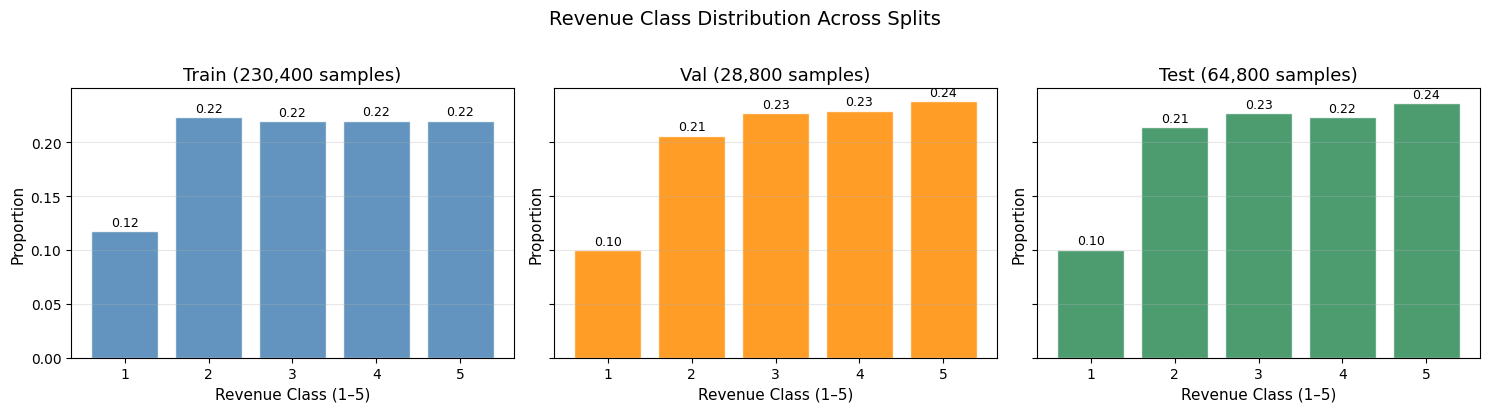


Class        Train       Val      Test
1            0.117     0.100     0.100
2            0.223     0.206     0.214
3            0.219     0.227     0.227
4            0.220     0.229     0.223
5            0.220     0.238     0.236


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
splits = [('Train', y_train), ('Val', y_val), ('Test', y_test)]
colors = ['steelblue', 'darkorange', 'seagreen']

for ax, (name, y), color in zip(axes, splits, colors):
    counts = pd.Series(y).value_counts(normalize=True).sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name} ({len(y):,} samples)', fontsize=13)
    ax.set_xlabel('Revenue Class (1–5)', fontsize=11)
    ax.set_ylabel('Proportion', fontsize=11)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.grid(axis='y', alpha=0.3)
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Revenue Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'dl_class_distribution.svg'),
            format='svg', bbox_inches='tight')
plt.show()

print(f'\n{"Class":<8}', end='')
for name, _ in splits:
    print(f'{name:>10}', end='')
print()
for cls in range(1, 6):
    print(f'{cls:<8}', end='')
    for _, y in splits:
        print(f'{(y == cls).mean():>10.3f}', end='')
    print()

In [28]:
print('=' * 65)
print('  FINAL TENSOR SHAPES')
print('=' * 65)
print(f'  X_train : {X_train.shape}   [N_train, {WINDOW_SIZE}, {NUM_FEATURES}]')
print(f'  y_train : {y_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  y_test  : {y_test.shape}')
print('=' * 65)
print(f'\n  Axis legend:')
print(f'    Axis 0 (N) = windows / samples')
print(f'    Axis 1 (T) = {WINDOW_SIZE} time steps  ← 24-hour lookback window')
print(f'    Axis 2 (F) = {NUM_FEATURES} features per time step  (was 13, now 15 with lat/lon):')
for i, col in enumerate(FEATURE_COLS):
    print(f'             [{i:2d}] {col}')

print('\nSanity checks:')
assert X_train.ndim == 3
assert X_train.shape[1] == WINDOW_SIZE
assert X_train.shape[2] == NUM_FEATURES
assert set(np.unique(y_train)) <= {1,2,3,4,5}
assert set(np.unique(y_test))  <= {1,2,3,4,5}
for split_name, arr in [('X_train',X_train),('X_val',X_val),('X_test',X_test)]:
    assert not np.isnan(arr).any(), f'NaN found in {split_name}!'
print('  All checks passed')

  FINAL TENSOR SHAPES
  X_train : (230400, 24, 15)   [N_train, 24, 15]
  y_train : (230400,)
  X_val   : (28800, 24, 15)
  y_val   : (28800,)
  X_test  : (64800, 24, 15)
  y_test  : (64800,)

  Axis legend:
    Axis 0 (N) = windows / samples
    Axis 1 (T) = 24 time steps  ← 24-hour lookback window
    Axis 2 (F) = 15 features per time step  (was 13, now 15 with lat/lon):
             [ 0] demand_count
             [ 1] total_engaged_minutes
             [ 2] speed_mph
             [ 3] airport_trip_count
             [ 4] passenger_count
             [ 5] profit_index
             [ 6] neighbor_demand_mean
             [ 7] lat_scaled
             [ 8] lon_scaled
             [ 9] hour_sin
             [10] hour_cos
             [11] dow_sin
             [12] dow_cos
             [13] is_weekend
             [14] is_blizzard

Sanity checks:
  All checks passed


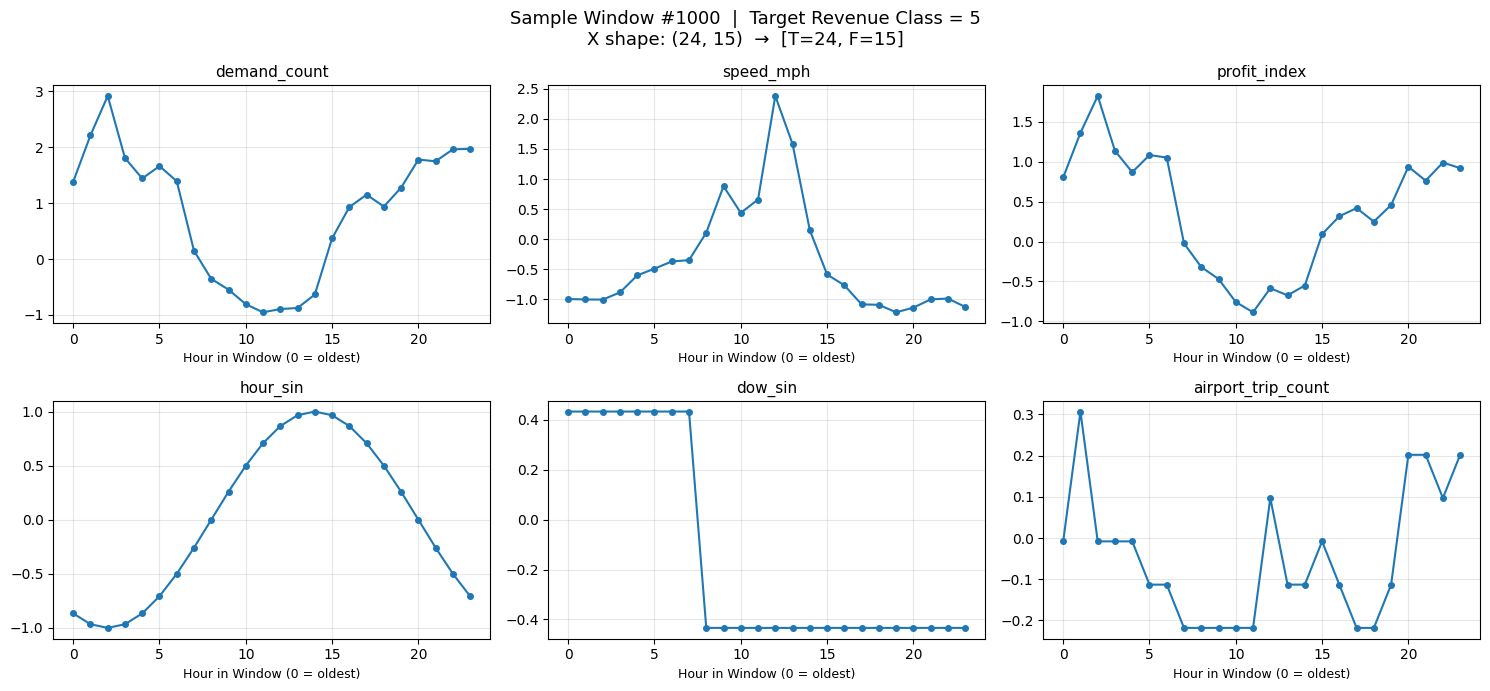

In [29]:
sample_idx = 1000
sample_X   = X_train[sample_idx]   # shape: (24, NUM_FEATURES)
sample_y   = y_train[sample_idx]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
plot_cols  = ['demand_count', 'speed_mph', 'profit_index',
               'hour_sin',    'dow_sin',   'airport_trip_count']

for ax, col in zip(axes.flat, plot_cols):
    col_idx = FEATURE_COLS.index(col)
    ax.plot(range(WINDOW_SIZE), sample_X[:, col_idx],
            marker='o', ms=4, linewidth=1.5)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Hour in Window (0 = oldest)', fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    f'Sample Window #{sample_idx}  |  Target Revenue Class = {sample_y}\n'
    f'X shape: {sample_X.shape}  →  [T={WINDOW_SIZE}, F={NUM_FEATURES}]',
    fontsize=13
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'dl_sample_window.svg'),
            format='svg', bbox_inches='tight')
plt.show()

In [30]:
print(f'Saving tensors → {OUTPUT_HDF5} …')

with h5py.File(OUTPUT_HDF5, 'w') as f:

    for split_name, X, y, c in [
        ('train', X_train, y_train, c_train),
        ('val',   X_val,   y_val,   c_val),
        ('test',  X_test,  y_test,  c_test),
    ]:
        grp = f.create_group(split_name)
        grp.create_dataset('X', data=X, compression='gzip', compression_opts=4)
        grp.create_dataset('y', data=y, compression='gzip', compression_opts=4)
        grp.create_dataset('cluster_id', data=c, compression='gzip', compression_opts=4)
        print(f'  {split_name:5s}: X={X.shape}, y={y.shape}')

    # Metadata
    f.attrs['window_size']    = WINDOW_SIZE
    f.attrs['num_features']   = NUM_FEATURES
    f.attrs['num_clusters']   = NUM_CLUSTERS
    f.attrs['feature_names']  = FEATURE_COLS
    f.attrs['thresholds']     = THRESHOLDS
    f.attrs['index_ceiling']  = INDEX_CEILING
    f.attrs['train_end']      = str(TRAIN_END)
    f.attrs['val_end']        = str(VAL_END)
    f.attrs['test_start']     = str(TEST_START)
    f.attrs['buffer_hours']   = BUFFER_HOURS
    f.attrs['created_by']     = '08_Deep_Learning_Data_Prep.ipynb'
    f.attrs['source_train']   = 'train_raw.parquet  (notebook 06)'
    f.attrs['source_test']    = 'test_raw.parquet   (notebook 06)'

file_mb = os.path.getsize(OUTPUT_HDF5) / 1e6
print(f'\nFile saved  : {OUTPUT_HDF5}')
print(f'File size   : {file_mb:.1f} MB')

Saving tensors → /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/dl_tensors/dl_tensors.h5 …
  train: X=(230400, 24, 15), y=(230400,)
  val  : X=(28800, 24, 15), y=(28800,)
  test : X=(64800, 24, 15), y=(64800,)

File saved  : /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/dl_tensors/dl_tensors.h5
File size   : 78.3 MB


In [31]:
npy_dir = os.path.join(DL_DATA_PATH, 'npy')
os.makedirs(npy_dir, exist_ok=True)

for name, arr in [
    ('X_train', X_train), ('y_train', y_train),
    ('X_val',   X_val),   ('y_val',   y_val),
    ('X_test',  X_test),  ('y_test',  y_test),
]:
    path = os.path.join(npy_dir, f'{name}.npy')
    np.save(path, arr)
    print(f'  Saved {name}.npy  →  shape {arr.shape}')

print(f'\nAll .npy files → {npy_dir}')

  Saved X_train.npy  →  shape (230400, 24, 15)
  Saved y_train.npy  →  shape (230400,)
  Saved X_val.npy  →  shape (28800, 24, 15)
  Saved y_val.npy  →  shape (28800,)
  Saved X_test.npy  →  shape (64800, 24, 15)
  Saved y_test.npy  →  shape (64800,)

All .npy files → /content/drive/MyDrive/SU Works/CPSC_5310_Project/saved_data/dl_tensors/npy
